# Giai đoạn 3 — Validation mạnh hơn: rolling-origin backtest và kiểm định Diebold-Mariano

Notebook này mở rộng Mục VI.1 của tài liệu gốc, giải quyết trực tiếp hạn chế thứ hai mà
Mục IX (Kết luận) tự nêu ra:

> *"Tập kiểm tra chỉ có 184 ngày nên chưa đủ để phân biệt dứt khoát bốn mô hình dẫn đầu,
> vốn chỉ cách nhau từ vài phần nghìn đến gần hai phần trăm WAPE; thứ hạng của chúng thay
> đổi theo cách gộp các lần cắt."*

Ba fold gốc (Fold 1, 2, 3 — mỗi fold nửa cuối một năm) cho ra đúng 2 con số WAPE mỗi mô
hình để lấy trung bình (CV = mean(Fold 2, Fold 3)). Với chênh lệch giữa các mô hình chỉ vài
phần nghìn, 2 con số không đủ để nói "mô hình A tốt hơn mô hình B" một cách có ý nghĩa
thống kê — có thể chỉ là may rủi của đúng hai cửa sổ đó.

Notebook này làm hai việc:

1. **Mở rộng từ 3 fold lên 12 fold không chồng lấn** (rolling-origin, mỗi fold 6 tháng,
   đệm 31 ngày, trải từ giữa 2016 đến giữa 2022 — không chạm vào TEST_FOLD chính thức).
2. **Kiểm định Diebold-Mariano (có hiệu chỉnh Harvey-Leybourne-Newbold)** trên chuỗi sai số
   đã gộp từ 12 fold, để trả lời đúng câu hỏi: khác biệt WAPE giữa hai mô hình có ý nghĩa
   thống kê hay chỉ là nhiễu.

Dùng lại bộ 62 đặc trưng đã chốt ở [02_feature_engineering.ipynb](02_feature_engineering.ipynb)
(`features_h28_v2.csv`) — Giai đoạn này không thay đổi đặc trưng, chỉ đo lường mô hình
chính xác hơn.

## 1. Thiết lập

In [1]:
import itertools
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
IMAGES = ROOT / "images"
RESULTS.mkdir(exist_ok=True)
IMAGES.mkdir(exist_ok=True)

H = 28
TARGET = "revenue"
SEED = 42
TEST_FOLD = ("TEST", "2022-05-31", "2022-07-01", "2022-12-31")   # giữ nguyên, không đụng tới

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [2]:
df = pd.read_csv(DATA_PROCESSED / "features_h28_v2.csv", parse_dates=["date"])
features_info = json.loads((RESULTS / "02_features.json").read_text(encoding="utf-8"))
features = features_info["final_features"]

print(f"{len(df):,} dòng, từ {df.date.min().date()} đến {df.date.max().date()}")
print(f"{len(features)} đặc trưng, bộ đã chốt ở Giai đoạn 2: {features_info['chosen_set']}")

3,462 dòng, từ 2013-07-10 đến 2022-12-31
62 đặc trưng, bộ đã chốt ở Giai đoạn 2: B. + khuyến mãi mở rộng


In [3]:
def get_models(seed=SEED):
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    import lightgbm as lgb
    import xgboost as xgb

    boosting = dict(n_estimators=700, learning_rate=0.04, subsample=0.85,
                     colsample_bytree=0.85, reg_lambda=1.0, n_jobs=-1, random_state=seed)
    return {
        "DecisionTree": DecisionTreeRegressor(max_depth=8, min_samples_leaf=15, random_state=seed),
        "RandomForest": RandomForestRegressor(n_estimators=400, max_depth=14, min_samples_leaf=3,
                                               n_jobs=-1, random_state=seed),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                        max_depth=4, subsample=0.85, random_state=seed),
        "XGBoost": xgb.XGBRegressor(max_depth=5, tree_method="hist", **boosting),
        "LightGBM": lgb.LGBMRegressor(num_leaves=31, min_child_samples=20, subsample_freq=5,
                                       verbose=-1, **boosting),
    }


def split_by_date(df, train_end, valid_start, valid_end):
    train = df[df.date <= train_end]
    valid = df[(df.date >= valid_start) & (df.date <= valid_end)]
    return train, valid


def wape(y, p):
    y = np.asarray(y, float)
    p = np.clip(np.asarray(p, float), 0, None)
    return float(np.sum(np.abs(y - p)) / np.sum(y))


MODEL_NAMES = list(get_models().keys())
print("5 mô hình cây, cấu hình giống hệt tài liệu gốc:", MODEL_NAMES)

5 mô hình cây, cấu hình giống hệt tài liệu gốc: ['DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 2. Rolling-origin backtest: từ 3 fold lên 12 fold không chồng lấn

Mỗi fold dài 6 tháng (giống hình dạng Fold 1-3 gốc), đệm 31 ngày giữa mốc huấn luyện và
mốc kiểm định (dài hơn H=28, đúng quy tắc Mục VI.1 gốc). Bước nhảy cũng là 6 tháng nên các
fold **không chồng lấn thời gian** — mỗi ngày trong lịch sử chỉ được dùng làm kiểm định
đúng một lần, cho phép gộp dự báo của toàn bộ 12 fold thành một chuỗi sai số liên tục duy
nhất ở Mục 4 mà không đếm trùng ngày nào.

In [4]:
def generate_rolling_folds(start, cutoff, months=6, buffer_days=31):
    """Sinh các fold 6 tháng liên tiếp, không chồng lấn, dừng trước cutoff để không
    chạm vào TEST_FOLD chính thức (valid_start 2022-07-01)."""
    folds = []
    cur = pd.Timestamp(start)
    cutoff = pd.Timestamp(cutoff)
    i = 1
    while cur < cutoff:
        valid_start = cur
        valid_end = cur + pd.DateOffset(months=months) - pd.Timedelta(days=1)
        train_end = valid_start - pd.Timedelta(days=buffer_days)
        folds.append((f"Fold {i}", str(train_end.date()), str(valid_start.date()), str(valid_end.date())))
        cur = cur + pd.DateOffset(months=months)
        i += 1
    return folds


folds_extended = generate_rolling_folds("2016-07-01", "2022-05-01")
fold_table = pd.DataFrame(folds_extended, columns=["fold", "train_end", "valid_start", "valid_end"])
fold_table["n_valid_days"] = [(pd.Timestamp(e) - pd.Timestamp(s)).days + 1
                               for s, e in zip(fold_table.valid_start, fold_table.valid_end)]
print(f"{len(folds_extended)} fold, đệm {31} ngày (> H={H}), tổng"
      f" {fold_table.n_valid_days.sum():,} ngày kiểm định gộp lại — so với 3 fold gốc"
      f" (~366 ngày) và TEST gốc (184 ngày).")
fold_table

12 fold, đệm 31 ngày (> H=28), tổng 2,191 ngày kiểm định gộp lại — so với 3 fold gốc (~366 ngày) và TEST gốc (184 ngày).


,fold,train_end,valid_start,valid_end,n_valid_days
0,Fold 1,2016-05-31,2016-07-01,2016-12-31,184
1,Fold 2,2016-12-01,2017-01-01,2017-06-30,181
2,Fold 3,2017-05-31,2017-07-01,2017-12-31,184
3,Fold 4,2017-12-01,2018-01-01,2018-06-30,181
4,Fold 5,2018-05-31,2018-07-01,2018-12-31,184
5,Fold 6,2018-12-01,2019-01-01,2019-06-30,181
6,Fold 7,2019-05-31,2019-07-01,2019-12-31,184
7,Fold 8,2019-12-01,2020-01-01,2020-06-30,182
8,Fold 9,2020-05-31,2020-07-01,2020-12-31,184
9,Fold 10,2020-12-01,2021-01-01,2021-06-30,181


## 3. Chạy 5 mô hình qua 12 fold, gộp toàn bộ dự báo lại

In [5]:
def evaluate_fold_predictions(df, fold, columns, model_name):
    _, train_end, valid_start, valid_end = fold
    train, valid = split_by_date(df, train_end, valid_start, valid_end)
    model = get_models()[model_name]
    model.fit(train[columns], np.log1p(train[TARGET].values))
    pred = np.expm1(model.predict(valid[columns]))
    return valid[["date", TARGET]].assign(model=model_name, fold=fold[0], pred=pred)


t0 = time.time()
records = []
for fold in folds_extended:
    for model_name in MODEL_NAMES:
        records.append(evaluate_fold_predictions(df, fold, features, model_name))
pooled = pd.concat(records, ignore_index=True)
print(f"Xong {len(folds_extended)} fold x {len(MODEL_NAMES)} mô hình = {len(records)} lần huấn"
      f" luyện, trong {time.time() - t0:.1f}s. Tổng {len(pooled):,} dòng dự báo.")

Xong 12 fold x 5 mô hình = 60 lần huấn luyện, trong 125.7s. Tổng 10,955 dòng dự báo.


## 4. Xếp hạng ổn định hơn qua 12 fold

In [6]:
fold_scores = []
for (model_name, fold_name), g in pooled.groupby(["model", "fold"]):
    fold_scores.append({"model": model_name, "fold": fold_name,
                         "WAPE": wape(g[TARGET].values, g["pred"].values), "n_days": len(g)})
fold_scores = pd.DataFrame(fold_scores)

summary = (fold_scores.groupby("model")["WAPE"].agg(["mean", "std", "min", "max"])
           .sort_values("mean"))
print(f"Xếp hạng theo WAPE trung bình qua {len(folds_extended)} fold (so với chỉ 2 fold gốc):\n")
print(summary.round(4).to_string())

model_order = summary.index.tolist()

Xếp hạng theo WAPE trung bình qua 12 fold (so với chỉ 2 fold gốc):

                    mean     std     min     max
model                                           
XGBoost           0.2661  0.1176  0.1648  0.5425
GradientBoosting  0.2707  0.1191  0.1715  0.5480
RandomForest      0.2731  0.1155  0.1730  0.5151
LightGBM          0.2754  0.1250  0.1720  0.5771
DecisionTree      0.3347  0.1420  0.2051  0.6454


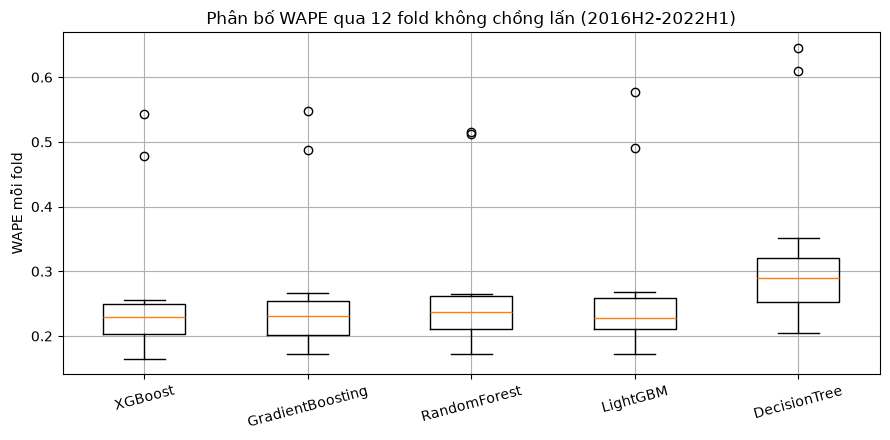

Nếu khoảng phân bố (box) của hai mô hình chồng lấn nhiều, chênh lệch trung bình
giữa chúng nhiều khả năng không có ý nghĩa — kiểm định chính thức ở Mục 5.


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data_by_model = [fold_scores.loc[fold_scores.model == m, "WAPE"].values for m in model_order]
ax.boxplot(data_by_model, tick_labels=model_order)
ax.set_ylabel("WAPE mỗi fold")
ax.set_title(f"Phân bố WAPE qua {len(folds_extended)} fold không chồng lấn (2016H2-2022H1)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(IMAGES / "03_wape_boxplot.png", dpi=110)
plt.show()

print("Nếu khoảng phân bố (box) của hai mô hình chồng lấn nhiều, chênh lệch trung bình")
print("giữa chúng nhiều khả năng không có ý nghĩa — kiểm định chính thức ở Mục 5.")

## 5. Kiểm định Diebold-Mariano — khác biệt có ý nghĩa thống kê không?

So sánh trực tiếp trung bình WAPE (như Mục VI.4 gốc) không cho biết chênh lệch có phải do
ngẫu nhiên hay không. Kiểm định Diebold-Mariano so sánh **chuỗi sai số đã gộp** của hai mô
hình trên đúng cùng những ngày kiểm định, trả lời câu hỏi đó trực tiếp.

Vì đây là dự báo cho khoảng H=28 ngày (không cập nhật lại mô hình theo từng ngày), sai số
tại các ngày liền kề có tương quan chuỗi — dùng t-test thường sẽ đánh giá thấp phương sai
và báo "có ý nghĩa" quá dễ dãi. Hiệu chỉnh Harvey-Leybourne-Newbold (1997) sửa lỗi này bằng
cách cộng thêm hiệp phương sai ở H-1 độ trễ đầu tiên vào phương sai của chênh lệch sai số,
và co hẹp thống kê kiểm định theo cỡ mẫu nhỏ.

In [8]:
def diebold_mariano(e1, e2, h=H, loss="absolute"):
    """Kiểm định Diebold-Mariano với hiệu chỉnh mẫu nhỏ Harvey-Leybourne-Newbold (1997).
    d_t < 0 trung bình nghĩa là mô hình 1 có tổn thất thấp hơn (tốt hơn) mô hình 2.
    """
    e1, e2 = np.asarray(e1, float), np.asarray(e2, float)
    d = (e1 ** 2 - e2 ** 2) if loss == "squared" else (np.abs(e1) - np.abs(e2))
    T = len(d)
    d_mean = d.mean()

    var_d = np.var(d, ddof=0)
    for lag in range(1, min(h, T)):
        cov = np.mean((d[:-lag] - d_mean) * (d[lag:] - d_mean))
        var_d += 2 * cov
    var_d = max(var_d, 1e-12)

    dm_stat = d_mean / np.sqrt(var_d / T)
    correction = np.sqrt((T + 1 - 2 * h + h * (h - 1) / T) / T)
    dm_stat *= correction
    p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=T - 1))
    return float(dm_stat), float(p_value)


wide_pred = pooled.pivot_table(index="date", columns="model", values="pred")
actual = df.set_index("date").loc[wide_pred.index, TARGET]
assert wide_pred.isna().sum().sum() == 0, "có ngày thiếu dự báo ở một mô hình nào đó"
errors = pd.DataFrame({m: actual.values - wide_pred[m].values for m in wide_pred.columns},
                       index=wide_pred.index)
print(f"Chuỗi sai số đã gộp: {len(errors):,} ngày, {errors.shape[1]} mô hình")

Chuỗi sai số đã gộp: 2,191 ngày, 5 mô hình


In [9]:
dm_rows = []
for m1, m2 in itertools.combinations(model_order, 2):
    stat, p = diebold_mariano(errors[m1].values, errors[m2].values, h=H, loss="absolute")
    if p >= 0.05:
        better = "không phân biệt được"
    else:
        better = m1 if stat < 0 else m2
    dm_rows.append({"model_1": m1, "model_2": m2, "DM_stat": stat, "p_value": p,
                     "có ý nghĩa (p<0.05)": p < 0.05, "tốt hơn": better})

dm_table = pd.DataFrame(dm_rows)
print(dm_table.round(4).to_string(index=False))

         model_1          model_2  DM_stat  p_value  có ý nghĩa (p<0.05)              tốt hơn
         XGBoost GradientBoosting  -1.1471   0.2514                False không phân biệt được
         XGBoost     RandomForest  -1.6282   0.1036                False không phân biệt được
         XGBoost         LightGBM  -2.4456   0.0145                 True              XGBoost
         XGBoost     DecisionTree  -9.0931   0.0000                 True              XGBoost
GradientBoosting     RandomForest  -0.0874   0.9304                False không phân biệt được
GradientBoosting         LightGBM  -0.8815   0.3781                False không phân biệt được
GradientBoosting     DecisionTree  -6.8254   0.0000                 True     GradientBoosting
    RandomForest         LightGBM  -0.5846   0.5588                False không phân biệt được
    RandomForest     DecisionTree  -8.1296   0.0000                 True         RandomForest
        LightGBM     DecisionTree  -6.8450   0.0000         

**Đọc bảng:** `DM_stat` âm nghĩa là `model_1` có tổn thất trung bình thấp hơn `model_2`
(tổn thất = trị tuyệt đối sai số). Chỉ khi `p_value < 0.05` mới kết luận khác biệt có ý
nghĩa thống kê; nếu không, hai mô hình được xem là "không phân biệt được" trên bằng chứng
hiện có dù WAPE trung bình khác nhau vài phần trăm — đúng như tài liệu gốc đã nghi ngờ.

## 6. Tổng kết Giai đoạn 3

In [10]:
summary_out = summary.round(6).to_dict("index")
n_significant = int(dm_table["có ý nghĩa (p<0.05)"].sum())
n_pairs = len(dm_table)

print(f"Trong {n_pairs} cặp mô hình, {n_significant} cặp có khác biệt ý nghĩa thống kê"
      f" (p<0.05), {n_pairs - n_significant} cặp KHÔNG phân biệt được dù WAPE trung bình"
      f" khác nhau — xác nhận đúng nghi ngờ ở Mục IX tài liệu gốc, giờ có bằng chứng định"
      f" lượng thay vì chỉ suy luận từ cỡ mẫu nhỏ.")

best_model = model_order[0]
print(f"\nMô hình tốt nhất theo WAPE trung bình 12-fold: {best_model}")

report = {
    "n_folds": len(folds_extended),
    "folds": fold_table.to_dict("records"),
    "ranking_mean_wape": summary_out,
    "dm_test": dm_table.to_dict("records"),
    "best_model": best_model,
    "n_significant_pairs": n_significant,
    "n_total_pairs": n_pairs,
}
(RESULTS / "03_validation.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, default=lambda o: o.tolist()),
    encoding="utf-8")
print("Đã ghi results/03_validation.json")

Trong 10 cặp mô hình, 5 cặp có khác biệt ý nghĩa thống kê (p<0.05), 5 cặp KHÔNG phân biệt được dù WAPE trung bình khác nhau — xác nhận đúng nghi ngờ ở Mục IX tài liệu gốc, giờ có bằng chứng định lượng thay vì chỉ suy luận từ cỡ mẫu nhỏ.

Mô hình tốt nhất theo WAPE trung bình 12-fold: XGBoost
Đã ghi results/03_validation.json


**Quyết định rút ra cho Giai đoạn 4 (modeling nâng cao):** thay vì chọn một mô hình duy
nhất bằng 2 con số CV như Mục VI gốc, Giai đoạn 4 nên **tuning và so sánh có trọng tâm** các
mô hình không bị loại bởi kiểm định DM ở trên (nếu vài mô hình "không phân biệt được" với
mô hình tốt nhất, dồn công sức tuning cho một mình LightGBM là bỏ sót — nên thử tuning cả
nhóm dẫn đầu rồi kiểm định DM lại), và xem xét ensemble/blend giữa các mô hình dẫn đầu thay
vì chọn một, vì bằng chứng hiện có không đủ mạnh để loại hẳn các ứng viên còn lại.